In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
import re
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ GPU kullanılıyor")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("⚠️ GPU yok, CPU kullanılıyor")


✅ GPU kullanılıyor
GPU: Tesla T4


In [4]:
df = pd.read_csv("articles_clean.csv")
df.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...


In [ ]:
df["combined_text"].iloc[0]


'i̇nsansız hava araçları için manyetik rezonans kuplaj ile şarj i̇stasyonu tasarımı i̇nsansız hava araçları (i̇ha) çeşitli alanlarda kullanılabilen elektronik sistemlerdir. gerçekleştirilen bu çalışmada, i̇ha’da kullanılan lityum bataryalar için manyetik rezonans kuplaj yöntemi kullanılarak bir şarj istasyonu tasarlanmıştır. devre tasarımlarının analizleri, matlab ve pspice programları sayesinde gerçekleştirilmiştir. ayrıca; şarj cihazında kullanılan bobinler, ansys maxwell programı kullanılarak tasarlanmıştır. tasarlanan şarj istasyonu ile 12 cm’den 3w gücündeki lityum bataryalar şarj edilmiştir. tasarlanan sistem ile i̇ha’nın bataryası şarj olurken bile uçmasına imkân sağlanmaktadır. insansız hava aracı (i̇ha), lityum batarya, manyetik rezonanslı kuplaj, kablosuz güç transferi.'

### DistilBERT

Bu çalışmada DistilBERT, metinleri yoğun vektörlere (embedding) dönüştürerek cümle ve dokümanlar arası anlamsal benzerliği ölçmek için kullanılan bir Transformer modelidir.
DistilBERT, BERT’in damıtılmış (distilled) bir versiyonu olup daha az parametre ile daha hızlı çalışmayı hedefler.

Bu notebook’ta Hugging Face üzerinde yayınlanan distilbert-base-multilingual-cased modeli kullanılmıştır.

Temel özellikler:

🌍 Çok dilli yapıdadır (Türkçe dahil)

⚡ BERT’e göre daha hafif ve hızlıdır (damıtma sayesinde)

🧠 Token-level çıktılar üretir; cümle/doküman embedding’i için pooling (ör. mean pooling) uygulanır

📐 Cosine similarity ile uyumludur

Not: SBERT gibi “doğrudan cümle embedding’i” üreten özel bir fine-tune modeli yerine,
burada DistilBERT’in son katman gizli durumları üzerinden mean pooling yapılarak embedding elde edilir.

In [5]:
model_name = 'distilbert-base-multilingual-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.to(device)
model.eval()

print(f"✅ Model loaded: {model_name}")

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded: distilbert-base-multilingual-cased


Token indices sequence length is longer than the specified maximum sequence length for this model (541 > 512). Running this sequence through the model will result in indexing errors


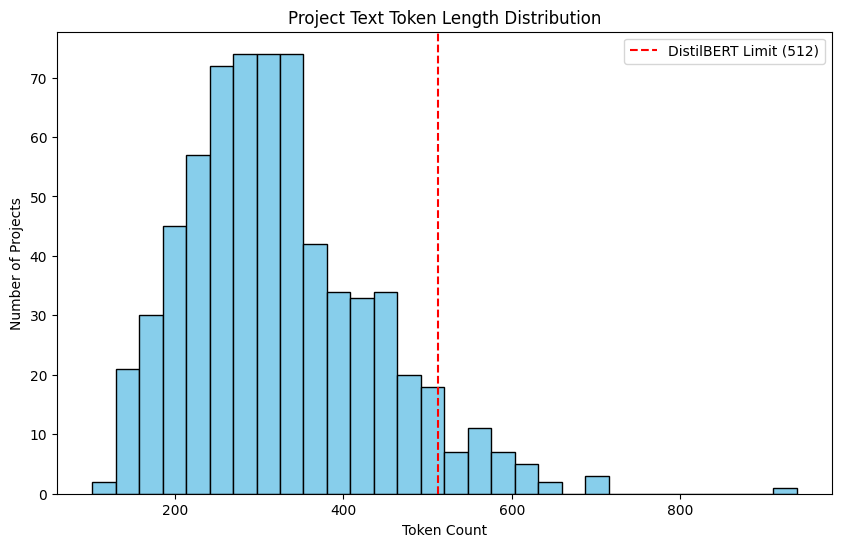

Ortalama token sayısı: 324.3813813813814
512 token'ı geçen proje sayısı: 41


In [6]:
# Her projenin model tarafından kaç 'token' olarak algılandığını hesaplar
df['token_counts'] = df['combined_text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True)))

# Token dağılımını görselleştirerek 512 sınırına yakınlığı kontrol eder
plt.figure(figsize=(10, 6))
plt.hist(df['token_counts'], bins=30, color='skyblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='DistilBERT Limit (512)')
plt.title('Project Text Token Length Distribution')
plt.xlabel('Token Count')
plt.ylabel('Number of Projects')
plt.legend()
plt.show()

# Veri kaybı olup olmadığını anlamak için özet istatistikler
print(f"Ortalama token sayısı: {df['token_counts'].mean()}")
print(f"512 token'ı geçen proje sayısı: {(df['token_counts'] > 512).sum()}")

In [7]:
# 1. Ağırlıkları Belirliyoruz
W_TITLE = 0.20
W_ABSTRACT = 0.70
W_KEYWORDS = 0.10

def mean_pooling(last_hidden_state: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """Attention mask'i dikkate alarak token embedding'lerinden mean pooling yapar."""
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)  # (B, T, 1)
    summed = (last_hidden_state * mask).sum(dim=1)                  # (B, H)
    counts = mask.sum(dim=1).clamp(min=1e-9)                        # (B, 1)
    return summed / counts


@torch.no_grad()
def get_embeddings(text):
    """
    Tek bir metin veya metin listesi için DistilBERT embedding üretir.
    - Boş veri gelirse 768 boyutlu sıfır vektörü döner.
    - Token-level çıktılardan mean pooling ile cümle/doküman embedding'i elde edilir.
    Dönüş tipi: NumPy Array (float32)
    """
    hidden_size = model.config.hidden_size

    if isinstance(text, str):
        if text.strip() == "":
            return np.zeros(hidden_size, dtype=np.float32)
        texts = [text]
        single_input = True
    else:
        texts = list(text)
        single_input = False

        cleaned_texts = []
        for t in texts:
            if isinstance(t, str) and t.strip() != "":
                cleaned_texts.append(t)
            else:
                cleaned_texts.append("")

        texts = cleaned_texts

        if len(texts) == 0:
            return np.empty((0, hidden_size), dtype=np.float32)

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    pooled = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])

    # Cosine similarity ve ağırlıklı birleştirme için normalize etmek faydalı olur
    pooled = F.normalize(pooled, p=2, dim=1)

    emb = pooled.detach().cpu().numpy().astype(np.float32)

    if single_input:
        return emb[0]
    return emb


# Pandas işlemlerine görsel ilerleme çubuğu (tqdm) ekler
tqdm.pandas()
print("🚀 DistilBERT ayrı alan embedding süreci başlatılıyor...")

# 2. Her alan için ayrı ayrı vektör üretiyoruz
df["title_embedding"] = df["title_tr_clean"].progress_apply(get_embeddings)
df["abstract_embedding"] = df["abstract_tr_clean"].progress_apply(get_embeddings)
df["keywords_embedding"] = df["keywords_tr_clean"].progress_apply(get_embeddings)

def combine_embeddings(row):
    """3 ayrı vektörü ağırlıklarına göre çarpar, toplar ve normalize eder."""
    v_title = np.array(row["title_embedding"], dtype=np.float32)
    v_abstract = np.array(row["abstract_embedding"], dtype=np.float32)
    v_keywords = np.array(row["keywords_embedding"], dtype=np.float32)

    # Ağırlıklı Toplam: w1*v1 + w2*v2 + w3*v3
    weighted_vector = (W_TITLE * v_title) + (W_ABSTRACT * v_abstract) + (W_KEYWORDS * v_keywords)

    # L2 Normalizasyon
    norm = np.linalg.norm(weighted_vector)
    if norm > 0:
        weighted_vector = weighted_vector / norm

    return weighted_vector.tolist()

print("\nAğırlıklı vektörler birleştiriliyor ve normalize ediliyor...")
# 3. Vektörleri birleştirip nihai "embedding" sütununu oluşturuyoruz
df["embedding"] = df.apply(combine_embeddings, axis=1)

print("\n✅ Ağırlıklı Embedding işlemi başarıyla tamamlandı.")
print(f"Toplam Kayıt: {len(df)}")
print(f"Yeni Vektör Boyutu: {len(df['embedding'].iloc[0])}")

df.drop(columns=["title_embedding", "abstract_embedding", "keywords_embedding"], inplace=True)



🚀 DistilBERT ayrı alan embedding süreci başlatılıyor...


100%|██████████| 666/666 [00:06<00:00, 100.41it/s]



Ağırlıklı vektörler birleştiriliyor ve normalize ediliyor...

✅ Ağırlıklı Embedding işlemi başarıyla tamamlandı.
Toplam Kayıt: 666
Yeni Vektör Boyutu: 768


In [8]:
df.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding
0,2020-2021,İnsansız Hava Araçları için Manyetik Rezonans ...,İnsansız Hava Araçları (İHA) çeşitli alanlarda...,"insansız hava aracı (İHA), lityum batarya, man...",i̇nsansız hava araçları için manyetik rezonans...,i̇nsansız hava araçları (i̇ha) çeşitli alanlar...,"insansız hava aracı (i̇ha), lityum batarya, ma...",i̇nsansız hava araçları için manyetik rezonans...,228,"[-0.017321325838565826, -0.03383530676364899, ..."
1,2020-2021,İş Modeli Kanvas ve Yakın İş Modellerinin Savu...,Savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,savunma ve havacılık sanayinin rekabetçi koşul...,"savunma ve uçak sanayii, kanvas iş modeli, üni...",i̇ş modeli kanvas ve yakın i̇ş modellerinin sa...,253,"[-0.019580058753490448, -0.02916380763053894, ..."
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,251,"[-0.03283471241593361, -0.02629156969487667, 0..."
3,2020-2021,Modernization Projects,"Bu makalede, Türk Havacılık ve Uzay Sanayii LI...","artırılmış gerçeklik, model tabanlı izleme, iş...",modernization projects,"bu makalede, türk havacılık ve uzay sanayii li...","artırılmış gerçeklik, model tabanlı izleme, iş...","modernization projects bu makalede, türk havac...",158,"[-0.015543240122497082, -0.053361132740974426,..."
4,2020-2021,Döner Kanatlı Özgün Bir İHA Tasarımı ve Uçuş K...,Bu çalışmada 4 rotorlu döner kanatlı bir İnsan...,"İHA, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,bu çalışmada 4 rotorlu döner kanatlı bir i̇nsa...,"i̇ha, motor, uçuş kontrol kartı, özgün yazılım.",döner kanatlı özgün bir i̇ha tasarımı ve uçuş ...,210,"[-0.00982631091028452, -0.037287693470716476, ..."


In [9]:
def clean_text(text):
    # Metni temizleme
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[#%&*_=+<>]", "", text)
    return text.strip()

# Kullanıcıdan gelen ham veriler
raw_query_title = "Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi"

raw_query_abstract = (
    "Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak "
    "birebir muharebeler için otonom savunma algoritması geliştirilmiştir. "
    "Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda "
    "saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. "
    "Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan "
    "dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş "
    "manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı "
    "bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile "
    "algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir."
)

raw_query_keywords = "bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları."

# ARAMAYI DA AĞIRLIKLI YAPIYORUZ
W_TITLE = 0.20
W_ABSTRACT = 0.70
W_KEYWORDS = 0.10

# 1. Her sorgu parçası için ayrı vektör üret
vec_title = get_embeddings(clean_text(raw_query_title)).astype(np.float32)
vec_abstract = get_embeddings(clean_text(raw_query_abstract)).astype(np.float32)
vec_keywords = get_embeddings(clean_text(raw_query_keywords)).astype(np.float32)

# 2. Vektörleri ağırlıklarıyla çarp ve topla
query_vector = (W_TITLE * vec_title) + (W_ABSTRACT * vec_abstract) + (W_KEYWORDS * vec_keywords)

# 3. Formülün bozulmaması için normalize et
norm = np.linalg.norm(query_vector)
if norm > 0:
    query_vector = query_vector / norm

# Mevcut veri kümesini karşılaştırma için hazırlama
corpus_embeddings = np.array(df["embedding"].tolist(), dtype=np.float32)  # (N, H)

# Kosinüs benzerliği hesaplama
similarity_scores = np.dot(corpus_embeddings, query_vector)

# Sonuçları raporlama ve benzerlik skoruna göre sıralama
df["similarity_score"] = similarity_scores
top_results = df.sort_values(by="similarity_score", ascending=False)

# En benzer ilk 5 sonuç
print("\n--- Özet Ağırlıklı Arama Sonuçları ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].head(5))

print("\n", "*"*215)

# En az benzer son 5 sonuç
print("\n--- En Az Benzer Sonuçlar ---")
with pd.option_context('display.max_colwidth', None):
    display(top_results[["Year","Title_TR", "Abstract_TR","similarity_score"]].tail(5))




--- Özet Ağırlıklı Arama Sonuçları ---


,Year,Title_TR,Abstract_TR,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasının Geliştirilmesi,"Bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. Algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. Algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. Algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. MATLAB/Simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir.",1.000000
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar Kullanılarak Karar Verme Algoritmalarının Gerçeklenmesi ve Analizi,"Hava muharebelerinde otonominin giderek yaygın- laşmasıyla birlikte görevleri yüksek başarı oranlarıyla gerçekleş- tirecek uçuş algoritmalarının önemi her geçen gün artmaktadır. Bu çalışmada ise bulanık mantık destekli karar verme algoritma- ları ile otonom hava muharebelerinde meydana gelebilecek du- rumlar için bulanık mantık kural tabanı ile MATLAB kullanıla- rak uçuş senaryolarının simülasyon ortamında gerçeklenmesi amaçlanmıştır. Uçakların it dalaşındaki etkinliği değerlendiril- mektedir. Algoritma, hedef uçak hareketine bağlı olarak bulanık mantık kural tabanına göre uygun referans değerlerini üreterek saldırı manevraları gerçekleştirmektedir.",0.979404
576,2023-2024,Ölçeklendirilmiş Uçuş Test Uçakları için Thrust Vectoring Nozzle Mekanizması Tasarımı,"Bu proje, ölçeklendirilmiş uçuş test uçakları için özgün bir itki yönlendirme nozul mekanizmasının tasarlanması ve geliştirilmesini hedeflemektedir. Geleneksel aerodinamik kontrol sistemlerinin yetersiz kaldığı yüksek hücum açılarında ve perdövites-sonrası uçuş koşullarında uçakların manevra kabiliyetini artırmayı amaçlamaktadır. Bu yenilikçi tasarım, uçakların perdövites-sonrası manevralarını optimize ederek, özellikle yakın mesafe hava muharebesinde üstünlük sağlamayı hedefler. Uçuş testlerinden elde edilen verilerle tasarım sürekli iyileştirilecektir. Projenin başarı kriterleri arasında, nozul mekanizmasının uçakların manevra kabiliyetini artırmada etkili olması ve genel uçuş performansını optimize etmesi yer almaktadır.",0.969063
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantık ve Dinamik Programlama Kullanarak Karar Verme Algoritmasının Uygulanması ve Analizi","Bu çalışmada hava muharebesinde askeri pilotların başarı oranını artırmak için eğitim amaçlı kullanılmak üzere hava araçlarının aerodinamik yapıları göz önünde bulundurularak Unity oyun motorunda simülasyon ortamı hazırlanmıştır. Bu ortamda eğitim görmekte olan pilotlarla yarışacak, düşman pilot olarak görev alacak, pilotların manevralarını analiz ederek sürekli kendi stratejisini belirleyecek bir yapay zekâ modeli geliştirilmiştir. Yapay zekâ modelinin tasarımında derin öğrenme ve takviyeli öğrenme tekniklerini birleştiren Derin Q Ağları (DQN) kullanılmıştır. Bu alanda belirttiğimiz tekniklerle, geliştirdiğimiz eğitim simülasyon ortamının bir araya getirilmesi çalışmamızın temel katkısıdır. Geliştirilen simülasyon sistemi ve DQN tabanlı yapay zekâ modeli, hava muharebesi eğitimlerinde kullanılacak bir eğitim aracının temellerini oluşturmuştur.",0.968400
501,2023-2024,İHA'ların İç Mekan Navigasyonu için Lidar Tabanlı Bir Yöntemin Geliştirilmesi,"Bu proje, geleneksel GNSS sinyallerinin bulunmadığı iç mekanlarda insansız hava araçlarının (İHA) navigasyonu ile ilgili problemi ele almayı amaçlamaktadır. Proje ekibi, Türk Havacılık ve Uzay Sanayii (TUSAŞ) ile iş birliği içinde, bu probleme LiDAR teknolojisini kullanarak yaklaşmaktadır ve yüksek hassasiyetli 2D haritalama ve lokalizasyonu hedeflemektedir. Proje ayrıca, üretilen haritalar kullanılarak İHA'ların 


 ***********************************************************************************************************************************************************************************************************************

--- En Az Benzer Sonuçlar ---


,Year,Title_TR,Abstract_TR,similarity_score
426,2023-2024,Dijital Kontrollü DC-DC Dönüştürücü Tasarımı,"İleri yönlü dönüştürücülerin topolojisi araştırılmış ve avantaj ve dezavantajları hakkında bilgi verilmiştir. İleri yönlü dönüştürücüde, transformatörün mıknatıslama endüktansının resetlenmesinin farklı şekillerde yapılması ile farklı ileri yönlü dönüştürücü topolojileri elde edilmiştir. TUSAŞ Lift-Up projesi kapsamında havacılık alanında kullanılan DC-DC dönüştürücüler ile ilgili de literatür araştırılması yapılarak kullanımının basit olması ve resetleme sargısı sorunun ortadan kaldırılması amacıyla RCD Bastırma Hücreli İleri Yönlü Dönüştürücü tasarımı tercih edilmiştir. TUSAŞ Lift-Up proje isterlerinde bu devrenin dijital kontrollü DC-DC dönüştürücü olarak tasarımı yapılmıştır. DC- DC dönüştürücünün PSIM programı ile simülasyonu gerçekleştirilmiş olup simülasyon sonuçları tezde sunulmuştur. Daha sonra Altium Designer programı ile dijital kontrollü tasarımı gerçekleştirilerek baskı devresi çıkarılmıştır. Baskı devre üzerine devre elemanlarının lehim işlemi yapılmış ve sonuçlar gözlemlenmiştir.",0.895427
370,2022-2023,Toz Yatağı Eklemeli Üretim Prosesleriyle Üretilen Ti6Al4V Parçaların Yüzey Pürüzlülüğünü Azaltmaya Yönelik İkincil Yüzey İşlemi Tasarımı,"Eklemeli imalat, dijital tasarımlar kullanılarak üç boyutlu nesnelerin katman katman üretildiği bir yöntemdir. Ancak bu yöntem genellikle yüksek yüzey pürüzlülüğü sorunuyla sonuçlanır, bu da ürünlerin mekanik özelliklerini etkileyebilmektedir. Bu araştırma, A.M. parçalarındaki yüzey pürüzlülüğü sorununu ele almak için ikincil işlemlere odaklanmaktadır. Yüzey pürüzlülüğünü azaltmak için elektro- polisaj, kimyasal polisaj ve kumlama gibi yöntemler araştırılmıştır. Ayrıca termal oksidasyon ve kumlama yöntemleri birleştirilerek yeni bir hibrit yöntem önerilmiş ve incelenmiştir. Araştırmanın bulguları, A.M. parçalarında yüzey pürüzlülüğünün azaltılmasına yönelik pratik bir yaklaşım sunmaktadır",0.894614
60,2020-2021,Ulusal Savunma Sanayiinde Lif Bazlı Kompozitlerin İncelenmesi,"Bu projede, savunma ve havacılık endüstrisinde kullanılmak üzere lif bazlı kompozit malzemeler için literatür araştırması yapılmıştır. Bu çalışmalar kapsamında braiding teknolojisi kullanılarak karbon lifi takviyeli boru şeklinde braided kompozit yapısı elde etmek amaçlanmıştır. Bu amaç doğrultusunda elde edilen kompozit malzeme yapısının özellikleri incelenmiştir.",0.894230
356,2022-2023,Sis Hadisesinin Uçuşa Etkisi ve İstanbul Uluslararası Havalimanı’nda Meydana Gelen Sis Hadiselerinin Analizi ve Tahmini,"Çalışmada, İstanbul Uluslararası Havalimanı (International Civil Aviation Organisation (ICAO) kodu: LTFM)’nın 2019-2021 yılları arasındaki 3 yıllık, İstanbul Atatürk Uluslararası Havalimanı (ICAO kodu: LTBA)’nın ve İstanbul Sabiha Gökçen Uluslararası Havalimanı (ICAO kodu: LTFJ)’nin ise 2012-2021 yılları arasındaki 10 yıllık meteorolojik verileri incelenerek sis analizi yapılmıştır. Analiz kısmından sonra ise LTFM’ye ait 4.5 yıllık veri ile korelasyon çalışması yaparak ve fog stability index (FOGSİ) indeksi hesaplanarak sis tahmini yapılmıştır. LTFM’de 3 yıllık periyotta 47 gün, LTBA’da 10 yıllık periyotta 36 gün, LTFJ’de 10 yıllık periyotta 200 gün sisli gün tespit edilmiştir. Yapılan tahmin çalışmasında ise fog stability index (FOGSİ)’in LTFM’deki sisi tahmin etmede başarısız olduğu sonucuna varılmıştır. LTFM’yi en iyi temsil edecek kendi sis kararlılık index çalışmamız devam etmektedir.",0.889908
341,2022-2023,"Poliüretan Bazlı Hidrofilik, Saydam Kaplama Geliştirilmesi","Bu çalışmada polikarbonat üzerinde poliüretan bazlı, saydam, hidrofilik kaplama geliştirilmesi çalışılmıştır. Elimizde olan PUD, HDI, NMP ile kaplamanın özelliklerinin geliştirilmesi çalışılmıştır. Hidrofilikliği sağlamak için “korona plazma” yöntemi seçilerek temas açısının düşürülmesi denenmiştir.",0.874836


In [10]:
df["combined_text"].iloc[2]


'hava muharebesinde otonom savunma algoritmasının geliştirilmesi bu çalışma kapsamında, temel hava muharebesi manevraları kullanılarak birebir muharebeler için otonom savunma algoritması geliştirilmiştir. algoritma, hedef hava aracı ile beklenmedik bir şekilde karşılaşıldığı durumlarda saldırı üstünlüğünün sağlanması için en uygun muharebe manevrasını seçmeyi sağlamaktadır. algoritmanın test edilmesi amacıyla saldıran ve savunan uçaklar için doğrusal olmayan dinamik modeller kullanılmıştır. algoritmada manevra seçimi için temel savaş manevralarını içeren manevra kütüphanesinden uygun manevrayı seçecek kural tabanlı bir yapı önerilmiştir. matlab/simulink ortamında yapılan benzetim çalışmaları ile algoritmanın başarımı test edilmiş ve sonuçlar gösterilmiştir. bire-bir hava muharebesi, kural tabanlı yöntem, temel hava muharebe manevraları.'

In [11]:
df["embedding"].iloc[2]


[-0.03283471241593361,
 -0.02629156969487667,
 0.04315635561943054,
 0.023065736517310143,
 0.008550984784960747,
 0.03912805765867233,
 -0.006677516736090183,
 -0.006270409096032381,
 -0.01588563434779644,
 0.03965098783373833,
 -0.029214022681117058,
 0.06515352427959442,
 0.012724515981972218,
 0.009021691046655178,
 0.014906435273587704,
 -0.03594069182872772,
 0.03179698809981346,
 0.04174387827515602,
 -0.06087573617696762,
 -0.003380955895408988,
 -0.057443663477897644,
 0.00256714946590364,
 -0.01388214249163866,
 0.02558068186044693,
 0.03279215097427368,
 0.058961570262908936,
 -0.05820076912641525,
 -0.008282890543341637,
 -0.012733339332044125,
 -0.007853829301893711,
 0.0077848881483078,
 0.03825903311371803,
 -0.0020573451183736324,
 0.06725642830133438,
 -0.026051823049783707,
 -0.005282861180603504,
 -0.011075729504227638,
 0.009557959623634815,
 0.03992367163300514,
 -0.07042058557271957,
 0.0029841766227036715,
 0.03876377269625664,
 -0.04056829586625099,
 -0.00701928

In [12]:
top_results.head()


,Year,Title_TR,Abstract_TR,Keywords_TR,title_tr_clean,abstract_tr_clean,keywords_tr_clean,combined_text,token_counts,embedding,similarity_score
2,2020-2021,Hava Muharebesinde Otonom Savunma Algoritmasın...,"Bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,"bu çalışma kapsamında, temel hava muharebesi m...","bire-bir hava muharebesi, kural tabanlı yöntem...",hava muharebesinde otonom savunma algoritmasın...,251,"[-0.03283471241593361, -0.02629156969487667, 0...",1.000000
186,2021-2022,Otonom Hava Muharebelerinde Bulanık Metodlar K...,Hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,hava muharebelerinde otonominin giderek yaygın...,"otonom hava muharebeleri, bulanık mantık, kara...",otonom hava muharebelerinde bulanık metodlar k...,242,"[-0.02069544792175293, -0.029040182009339333, ...",0.979404
576,2023-2024,Ölçeklendirilmiş Uçuş Test Uçakları için Thrus...,"Bu proje, ölçeklendirilmiş uçuş test uçakları ...","itki yönlendirme, nozul mekanizması, perdövite...",ölçeklendirilmiş uçuş test uçakları için thrus...,"bu proje, ölçeklendirilmiş uçuş test uçakları ...","itki yönlendirme, nozul mekanizması, perdövite...",ölçeklendirilmiş uçuş test uçakları için thrus...,279,"[-0.02598709613084793, -0.0384238138794899, 0....",0.969063
479,2023-2024,"Hava Muharebesinde Oyun Teorisi, Bulanık Mantı...",Bu çalışmada hava muharebesinde askeri pilotla...,"Takviyeli Öğrenme, Oyun Teorisi, Simülasyon, D...","hava muharebesinde oyun teorisi, bulanık mantı...",bu çalışmada hava muharebesinde askeri pilotla...,"takviyeli öğrenme, oyun teorisi, simülasyon, d...","hava muharebesinde oyun teorisi, bulanık mantı...",322,"[-0.02850198559463024, -0.03268943727016449, 0...",0.968400
501,2023-2024,İHA'ların İç Mekan Navigasyonu için Lidar Taba...,"Bu proje, geleneksel GNSS sinyallerinin bulunm...","IHA, Otonom, LIDAR, SLAM, Navigasyon",i̇ha'ların i̇ç mekan navigasyonu için lidar ta...,"bu proje, geleneksel gnss sinyallerinin bulunm...","iha, otonom, lidar, slam, navigasyon",i̇ha'ların i̇ç mekan navigasyonu için lidar ta...,357,"[-0.013405011035501957, -0.033952441066503525,...",0.966922
